In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [151]:
grid_r = pd.read_csv('../output/grid_r.dat', sep='\s+', header=None).to_numpy()
grid_z = pd.read_csv('../output/grid_z.dat', sep='\s+', header=None).to_numpy()

n_pos = pd.read_csv('../output/positive_ions.dat', sep='\s+', header=None).to_numpy()
n_neg = pd.read_csv('../output/negative_ions.dat', sep='\s+', header=None).to_numpy()
n_ele = pd.read_csv('../output/electrons.dat', sep='\s+', header=None).to_numpy()

V = pd.read_csv('../output/potential.dat', sep='\s+', header=None).to_numpy()
rho = pd.read_csv('../output/charge_density.dat', sep='\s+', header=None).to_numpy()

E_r = pd.read_csv('../output/electric_field_r.dat', sep='\s+', header=None).to_numpy()
E_z = pd.read_csv('../output/electric_field_z.dat', sep='\s+', header=None).to_numpy()

# T = pd.read_csv('../output/temperature.dat', sep='\s+', header=None).to_numpy()

# it looks like wrong
# J_r = pd.read_csv('../output/current_density_r.dat', sep='\s+', header=None).to_numpy()
# J_z = pd.read_csv('../output/current_density_z.dat', sep='\s+', header=None).to_numpy()

# F_r = pd.read_csv('../output/electric_body_force_r.dat', sep='\s+', header=None).to_numpy()
# F_z = pd.read_csv('../output/electric_body_force_z.dat', sep='\s+', header=None).to_numpy()

q_e = 1.602176634e-19  # elementary charge [C]
K_pos = 2.9e-4 # mobility of positive ions [m2/s V]
K_neg = 2.9e-4 # mobility of negative ions [m2/s V]
K_ele = 0.4  # mobility of electrons [m2/s V]

J_r = q_e*K_pos*np.multiply(n_pos, E_r) - q_e*K_neg*np.multiply(n_neg, E_r) - q_e*K_ele*np.multiply(n_ele, E_r)
J_z = q_e*K_pos*np.multiply(n_pos, E_z) - q_e*K_neg*np.multiply(n_neg, E_z) - q_e*K_ele*np.multiply(n_ele, E_z)

F_r = np.multiply(rho, E_r)
F_z = np.multiply(rho, E_z)

# カラーマップ

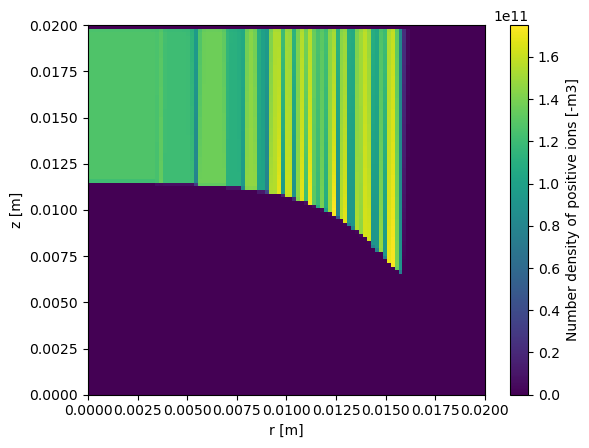

In [162]:
# plt.plot(V)
plt.imshow(np.flip(n_pos, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Number density of positive ions [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
plt.clim(0.0, np.max(np.abs(n_pos)))
# plt.title('Number density of positive ions [-m3]')

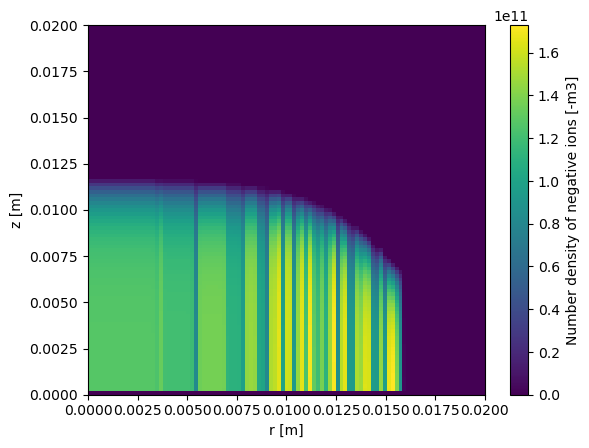

In [153]:
# plt.plot(V)
plt.imshow(np.flip(n_neg, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Number density of negative ions [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
plt.clim(0.0, np.max(np.abs(n_neg)))
# plt.title('Number density of positive ions [-m3]')

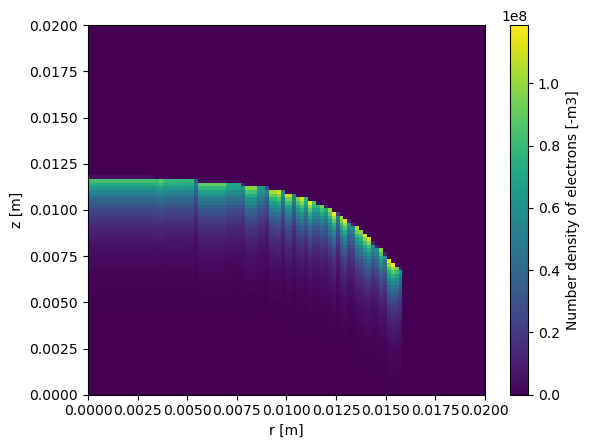

In [154]:
# plt.plot(V)
plt.imshow(np.flip(n_ele, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Number density of electrons [-m3]')
plt.xlabel('r [m]')
plt.ylabel('z [m]')
plt.clim(0.0, np.max(np.abs(n_ele)))
# plt.title('Number density of positive ions [-m3]')

Text(0, 0.5, 'z')

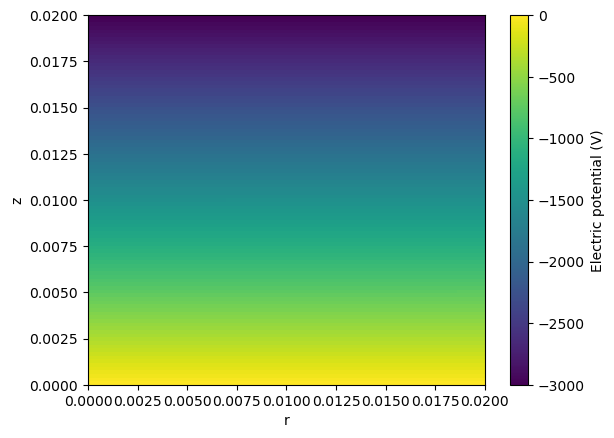

In [155]:
# plt.plot(V)
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')
# plt.title('Potential Distribution')

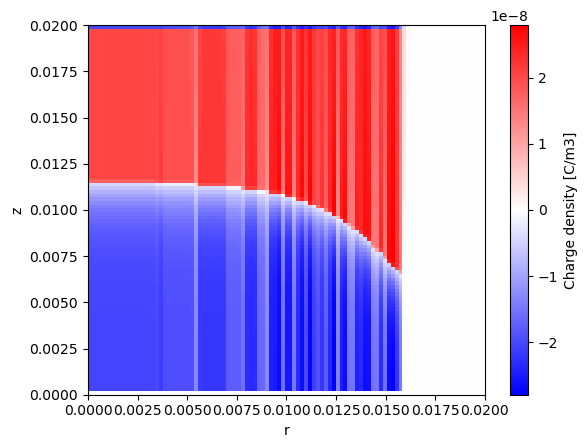

In [156]:
plt.imshow(np.flip(rho, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto', cmap='bwr')
plt.colorbar(label='Charge density [C/m3]')
plt.xlabel('r')
plt.ylabel('z')

max_rho = np.max(np.abs(rho))
plt.clim(- max_rho, max_rho)
# plt.title('Electric charge')

# ベクタープロット

Text(0.5, 1.0, 'Current density, Max: 4.326e-05 A/m2')

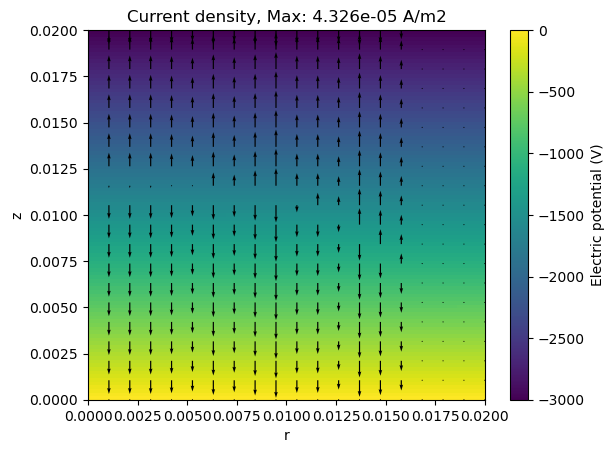

In [157]:
from scipy.ndimage import zoom

def plot_zoomed_data(value_r, value_z, zoom_factor):

    # # 拡大率を計算
    # zoom_factor = 0.2

    global grid_r, grid_z

    # データをリサイズ
    grid_r_new = zoom(grid_r, zoom_factor, order=3)
    grid_z_new = zoom(grid_z, zoom_factor, order=3)
    value_r_new = zoom(value_r, zoom_factor, order=3)
    value_z_new = zoom(value_z, zoom_factor, order=3)

    plt.quiver(grid_r_new, grid_z_new, value_r_new, value_z_new)

    return 

plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(J_r, J_z, 0.2)

J_max = np.sqrt(J_r*J_r + J_z*J_z).max()
plt.title(f'Current density, Max: {J_max:.3e} A/m2')


Text(0.5, 1.0, 'Electric body force, Max: 1.492e-04 N/m3')

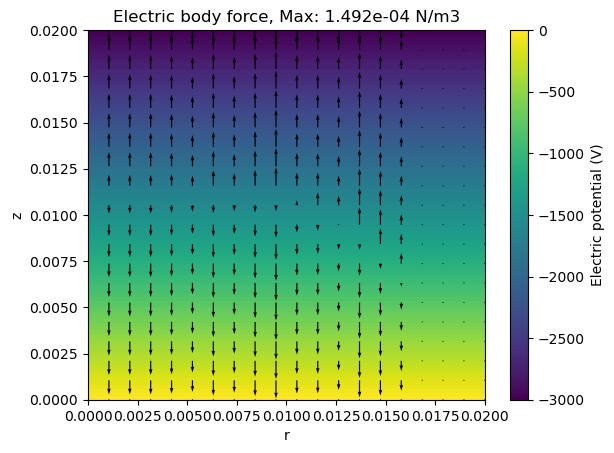

In [158]:
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(F_r, F_z, 0.2)

F_max = np.sqrt(F_r*F_r + F_z*F_z).max()
plt.title(f'Electric body force, Max: {F_max*1e-3:.3e} N/m3')

Text(0.5, 1.0, 'Electric field, Max: 8168.209 kV/m')

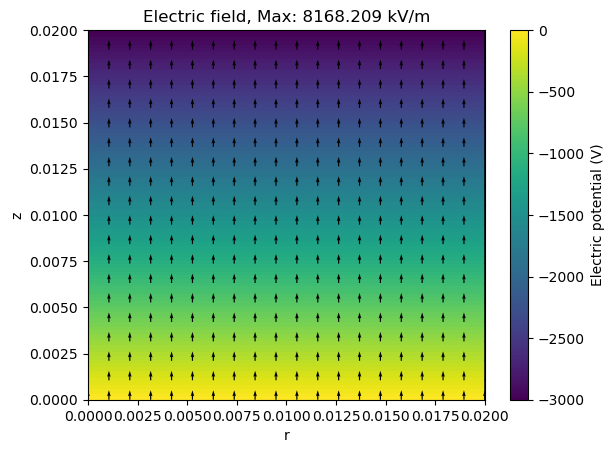

In [159]:
plt.imshow(np.flip(V, axis=0), extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plot_zoomed_data(E_r, E_z, 0.2)

E_max = np.sqrt(E_r*E_r + E_z*E_z).max()
plt.title(f'Electric field, Max: {E_max*1e-3:.3f} kV/m')

# ストリームプロット
plt.streamplotの仕様上grid_zを反転させている

(0.0, 0.01)

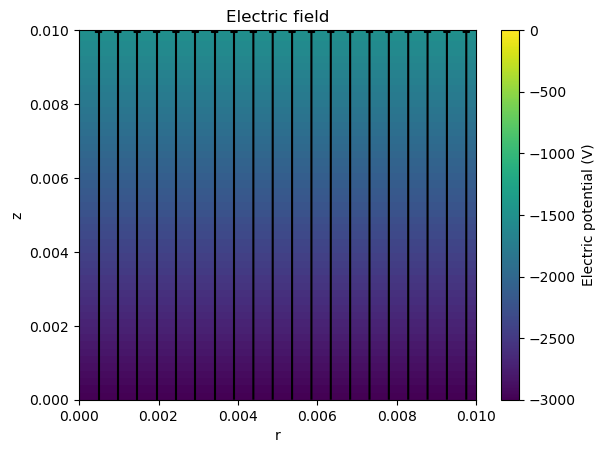

In [160]:
plt.imshow(V, extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plt.streamplot(grid_r, np.flip(grid_z, axis=0), E_r, E_z, density=1.4, linewidth=None, color='black')

plt.title('Electric field')
plt.xlim(0.0, 0.01)
plt.ylim(0.0, 0.01)

(0.0, 0.01)

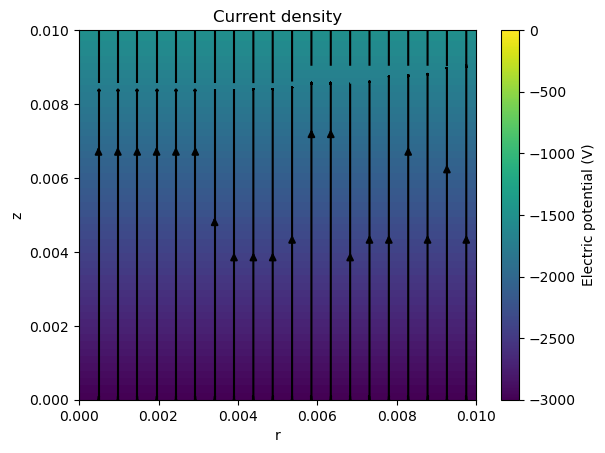

In [161]:
plt.imshow(V, extent=[grid_r.min(), grid_r.max(), grid_z.min(), grid_z.max()], origin='lower', aspect='auto')
plt.colorbar(label='Electric potential (V)')
plt.xlabel('r')
plt.ylabel('z')

plt.streamplot(grid_r, np.flip(grid_z, axis=0), J_r, J_z, density=1.4, linewidth=None, color='black')

plt.title('Current density')
plt.xlim(0.0, 0.01)
plt.ylim(0.0, 0.01)